# Importing

## Import Library

In [1]:
# This Python 3 environment comes with many helpful analytics libraries installed
# It is defined by the kaggle/python Docker image: https://github.com/kaggle/docker-python
# For example, here's several helpful packages to load

import numpy as np # linear algebra
import pandas as pd # data processing, CSV file I/O (e.g. pd.read_csv)
import matplotlib.pyplot as plt
import seaborn as sns
import warnings
warnings.filterwarnings('ignore')
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import Ridge
from sklearn.metrics import r2_score

# Input data files are available in the read-only "../input/" directory
# For example, running this (by clicking run or pressing Shift+Enter) will list all files under the input directory

import os
for dirname, _, filenames in os.walk('/kaggle/input'):
    for filename in filenames:
        print(os.path.join(dirname, filename))

# You can write up to 20GB to the current directory (/kaggle/working/) that gets preserved as output when you create a version using "Save & Run All" 
# You can also write temporary files to /kaggle/temp/, but they won't be saved outside of the current session

/kaggle/input/datasets/anadiskt/cryptocurrency-market-ecosystem-2014-2026/bitfarms_stock_price.csv
/kaggle/input/datasets/anadiskt/cryptocurrency-market-ecosystem-2014-2026/cleanspark_stock_price.csv
/kaggle/input/datasets/anadiskt/cryptocurrency-market-ecosystem-2014-2026/paypal_stock_price.csv
/kaggle/input/datasets/anadiskt/cryptocurrency-market-ecosystem-2014-2026/tesla_stock_price.csv
/kaggle/input/datasets/anadiskt/cryptocurrency-market-ecosystem-2014-2026/cifr_stock_price.csv
/kaggle/input/datasets/anadiskt/cryptocurrency-market-ecosystem-2014-2026/microstrategy_stock_price.csv
/kaggle/input/datasets/anadiskt/cryptocurrency-market-ecosystem-2014-2026/sp500_constituents.csv
/kaggle/input/datasets/anadiskt/cryptocurrency-market-ecosystem-2014-2026/ixic_index_price.csv
/kaggle/input/datasets/anadiskt/cryptocurrency-market-ecosystem-2014-2026/microstrategy_bitcoin_holdings.csv
/kaggle/input/datasets/anadiskt/cryptocurrency-market-ecosystem-2014-2026/dji_index_price.csv
/kaggle/input

## Import CSV And convert to DataFrame

In [2]:
df = pd.read_csv('/kaggle/input/datasets/anadiskt/cryptocurrency-market-ecosystem-2014-2026/dji_index_price.csv')

# Preprocessing

## Frist five row

In [3]:
df.head()

,Date,Open,High,Low,Close,Volume,Adj Close
0,1992-01-02,3152.100098,3172.629883,3139.310059,3172.399902,23550000,3172.399902
1,1992-01-03,3172.399902,3210.639893,3165.919922,3201.500000,23620000,3201.500000
2,1992-01-06,3201.500000,3213.330078,3191.860107,3200.100098,27280000,3200.100098
3,1992-01-07,3200.100098,3210.199951,3184.479980,3204.800049,25510000,3204.800049
4,1992-01-08,3204.800049,3229.199951,3185.820068,3203.899902,29040000,3203.899902


## last Five row

In [4]:
df.tail()

,Date,Open,High,Low,Close,Volume,Adj Close
8613,2026-03-19,46134.871094,46247.218750,45733.699219,46021.429688,482890000,46021.429688
8614,2026-03-20,45975.648438,46068.308594,45369.390625,45577.468750,1044540000,45577.468750
8615,2026-03-23,45803.820312,46712.328125,45803.820312,46208.468750,530140000,46208.468750
8616,2026-03-24,46099.859375,46400.820312,45769.691406,46124.058594,474450000,46124.058594
8617,2026-03-25,46314.238281,46718.421875,46196.910156,46429.488281,462991321,46429.488281


## Shape of our dataset

In [5]:
df.shape

(8618, 7)

## List out all columns

In [6]:
df.columns

Index(['Date', 'Open', 'High', 'Low', 'Close', 'Volume', 'Adj Close'], dtype='object')

## Datatype of each columns

In [7]:
df.dtypes

Date          object
Open         float64
High         float64
Low          float64
Close        float64
Volume         int64
Adj Close    float64
dtype: object

## Information of all Columns

In [8]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 8618 entries, 0 to 8617
Data columns (total 7 columns):
 #   Column     Non-Null Count  Dtype  
---  ------     --------------  -----  
 0   Date       8618 non-null   object 
 1   Open       8618 non-null   float64
 2   High       8618 non-null   float64
 3   Low        8618 non-null   float64
 4   Close      8618 non-null   float64
 5   Volume     8618 non-null   int64  
 6   Adj Close  8618 non-null   float64
dtypes: float64(5), int64(1), object(1)
memory usage: 471.4+ KB


## Check Null Value

In [9]:
df.isnull().sum()

Date         0
Open         0
High         0
Low          0
Close        0
Volume       0
Adj Close    0
dtype: int64

## Check Dupicate Value

In [10]:
df.duplicated().sum()

np.int64(0)

## Summary

In [11]:
df.describe()

,Open,High,Low,Close,Volume,Adj Close
count,8618.000000,8618.000000,8618.000000,8618.000000,8.618000e+03,8618.000000
mean,16101.296967,16194.955034,16004.288736,16105.027205,2.112142e+08,16105.027205
std,11064.611201,11118.984089,11007.751718,11066.356970,1.512298e+08,11066.356970
min,3136.600098,3172.629883,3095.790039,3136.600098,8.410000e+06,3136.600098
25%,9052.192627,9125.842529,8970.622314,9053.892334,8.487250e+07,9053.892334
50%,11406.214844,11477.734863,11331.270020,11409.435059,2.045150e+08,11409.435059
75%,21818.250000,21910.032227,21711.804688,21805.177734,2.966125e+08,21805.177734
max,50243.148438,50512.789062,50115.031250,50188.140625,1.412960e+09,50188.140625


# EDA

In [12]:
def show_fig():
    plt.tight_layout()
    plt.show()

plot_no = 1

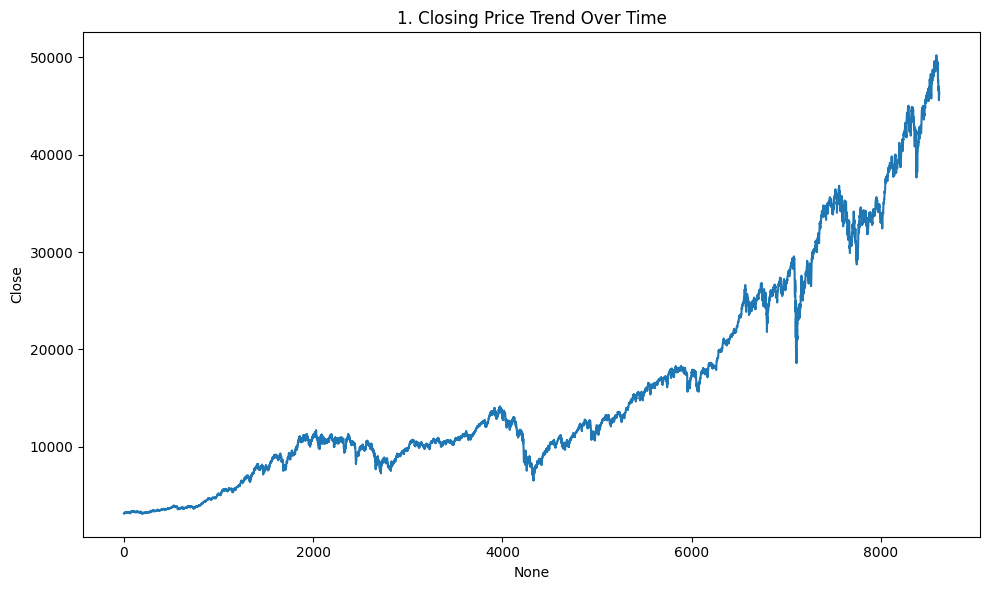

In [13]:
fig = plt.figure(figsize=(10,6))
sns.lineplot(x=df.index, y=df['Close'])
plt.title(f'{plot_no}. Closing Price Trend Over Time')
show_fig()
plot_no += 1

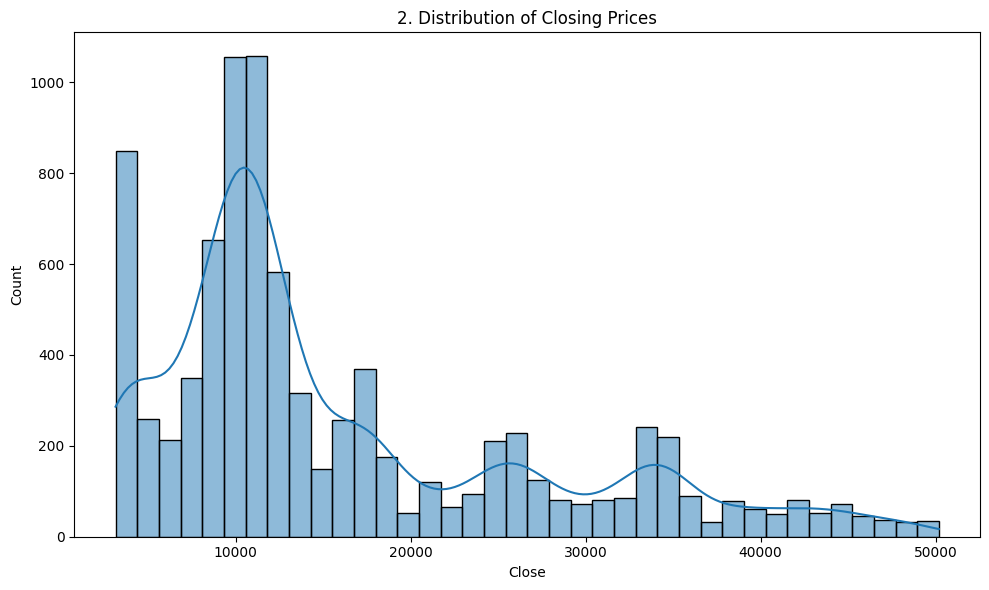

In [14]:
fig = plt.figure(figsize=(10,6))
sns.histplot(df['Close'], kde=True)
plt.title(f'{plot_no}. Distribution of Closing Prices')
show_fig()
plot_no += 1

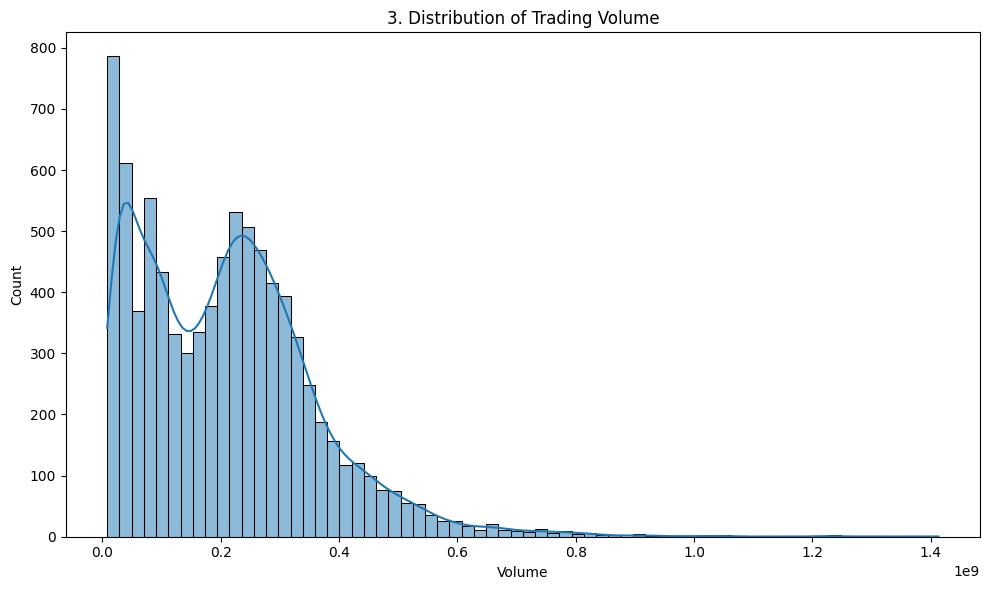

In [15]:
fig = plt.figure(figsize=(10,6))
sns.histplot(df['Volume'], kde=True)
plt.title(f'{plot_no}. Distribution of Trading Volume')
show_fig()
plot_no += 1

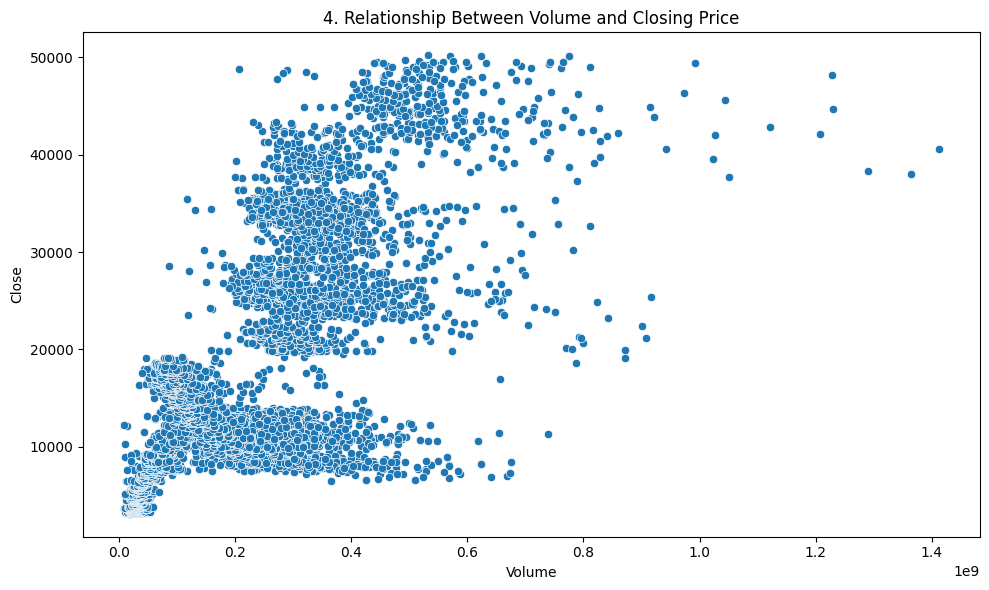

In [16]:
fig = plt.figure(figsize=(10,6))
sns.scatterplot(x=df['Volume'], y=df['Close'])
plt.title(f'{plot_no}. Relationship Between Volume and Closing Price')
show_fig()
plot_no += 1

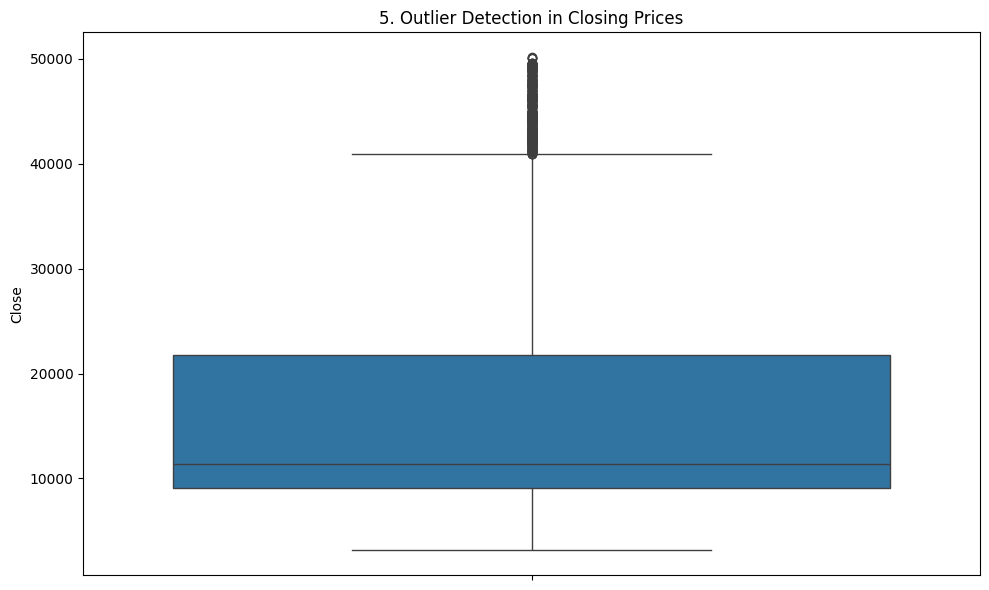

In [17]:
fig = plt.figure(figsize=(10,6))
sns.boxplot(y=df['Close'])
plt.title(f'{plot_no}. Outlier Detection in Closing Prices')
show_fig()
plot_no += 1

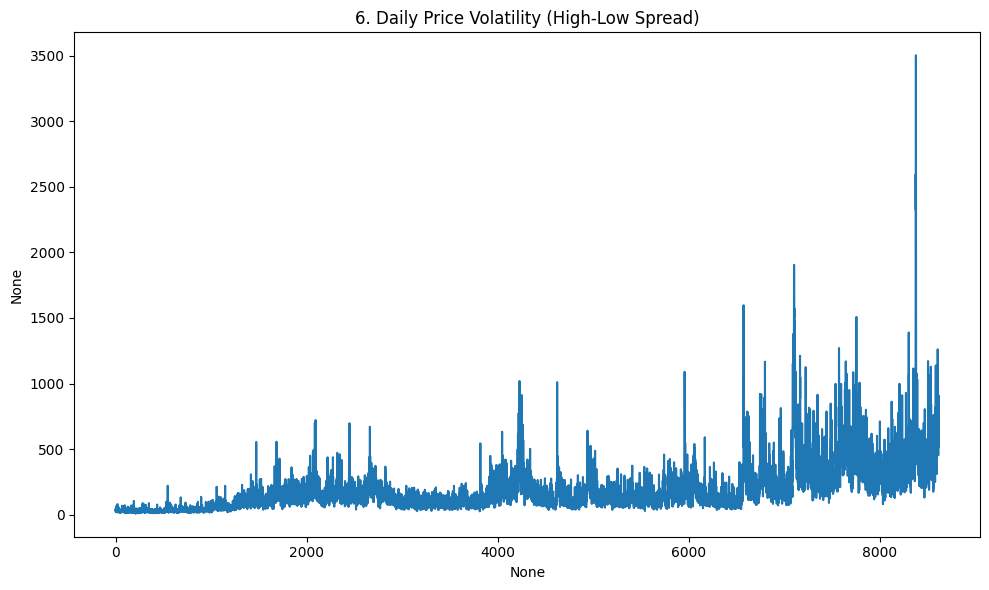

In [18]:
fig = plt.figure(figsize=(10,6))
sns.lineplot(x=df.index, y=df['High'] - df['Low'])
plt.title(f'{plot_no}. Daily Price Volatility (High-Low Spread)')
show_fig()
plot_no += 1

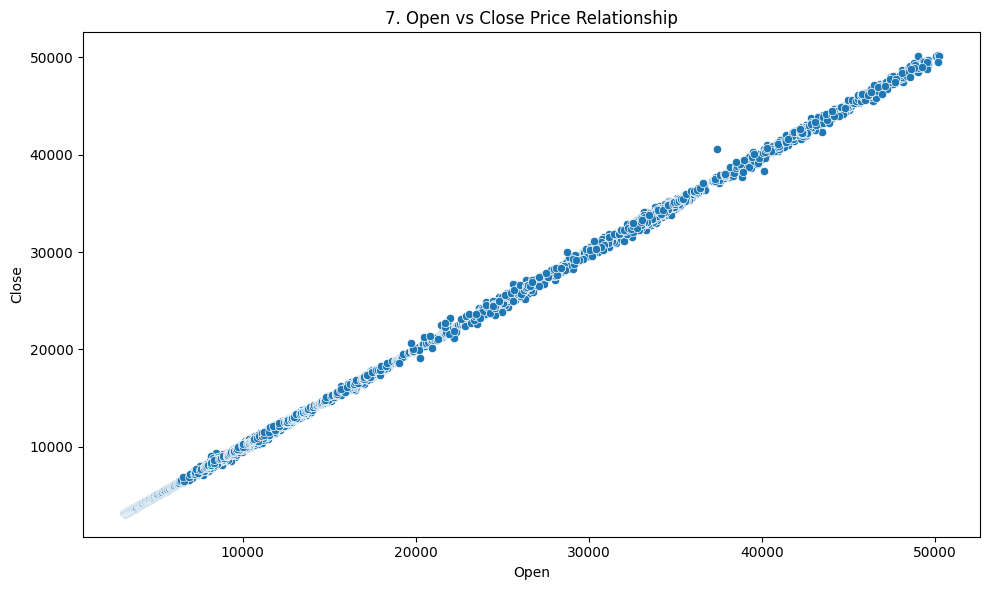

In [19]:
fig = plt.figure(figsize=(10,6))
sns.scatterplot(x=df['Open'], y=df['Close'])
plt.title(f'{plot_no}. Open vs Close Price Relationship')
show_fig()
plot_no += 1

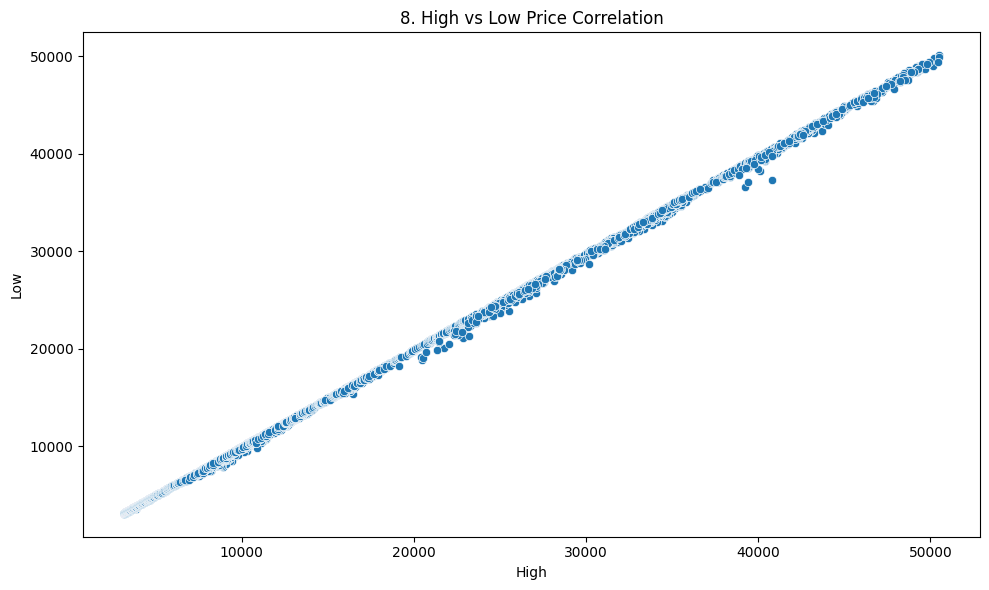

In [20]:
fig = plt.figure(figsize=(10,6))
sns.scatterplot(x=df['High'], y=df['Low'])
plt.title(f'{plot_no}. High vs Low Price Correlation')
show_fig()
plot_no += 1

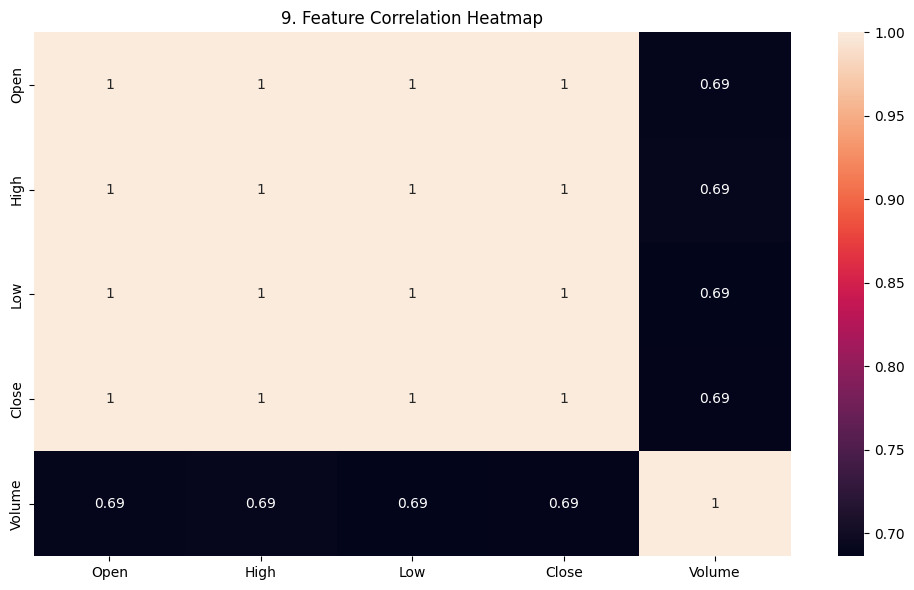

In [21]:
fig = plt.figure(figsize=(10,6))
sns.heatmap(df[['Open','High','Low','Close','Volume']].corr(), annot=True)
plt.title(f'{plot_no}. Feature Correlation Heatmap')
show_fig()
plot_no += 1

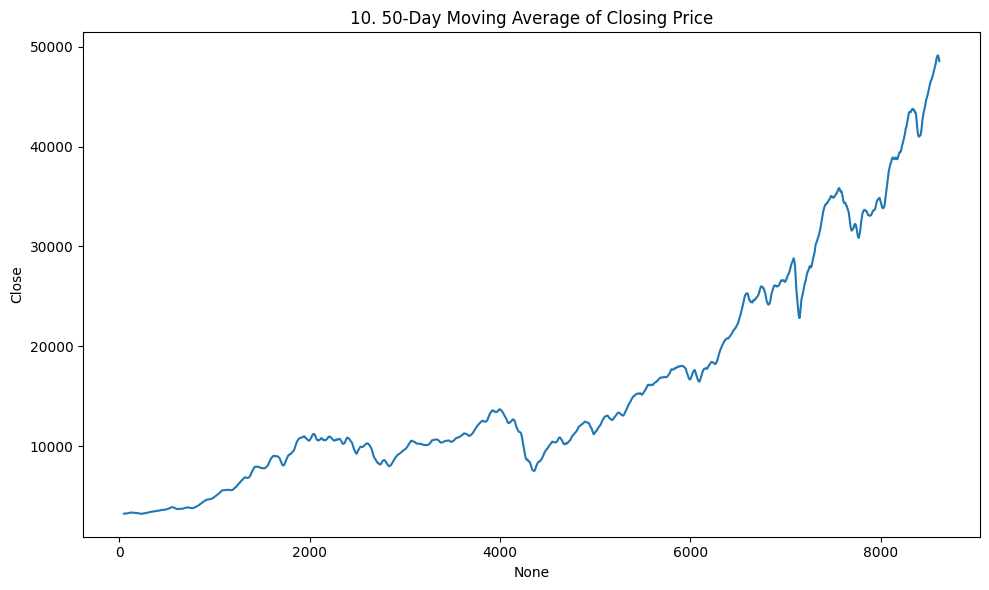

In [22]:
fig = plt.figure(figsize=(10,6))
sns.lineplot(x=df.index, y=df['Close'].rolling(50).mean())
plt.title(f'{plot_no}. 50-Day Moving Average of Closing Price')
show_fig()
plot_no += 1

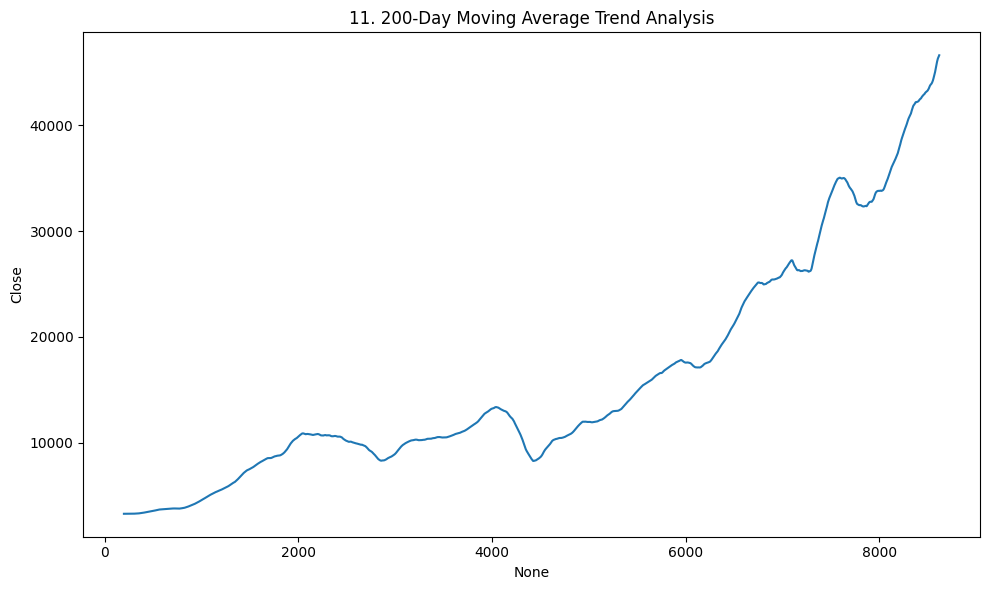

In [23]:
fig = plt.figure(figsize=(10,6))
sns.lineplot(x=df.index, y=df['Close'].rolling(200).mean())
plt.title(f'{plot_no}. 200-Day Moving Average Trend Analysis')
show_fig()
plot_no += 1

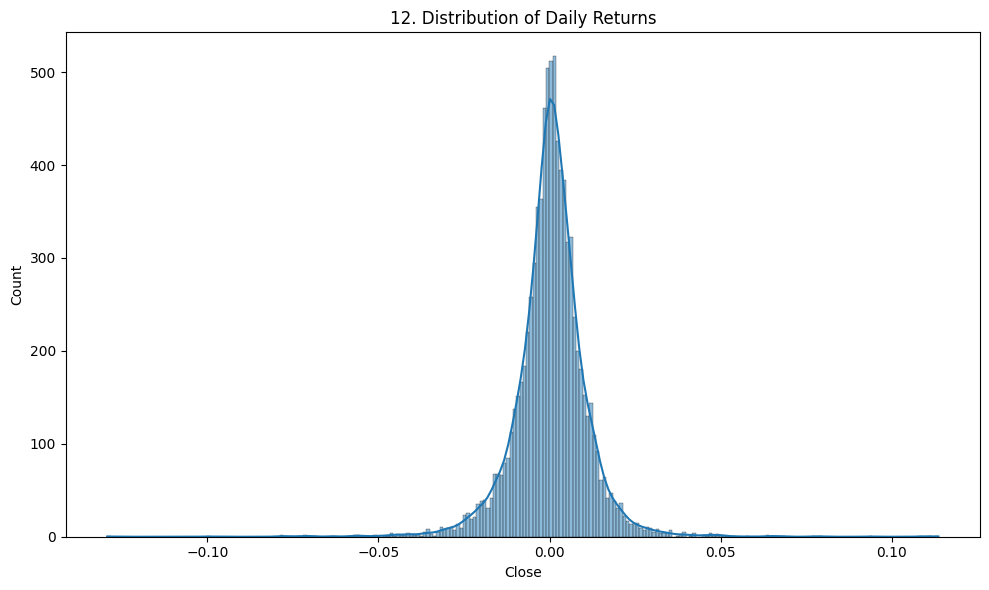

In [24]:
fig = plt.figure(figsize=(10,6))
returns = df['Close'].pct_change()
sns.histplot(returns.dropna(), kde=True)
plt.title(f'{plot_no}. Distribution of Daily Returns')
show_fig()
plot_no += 1

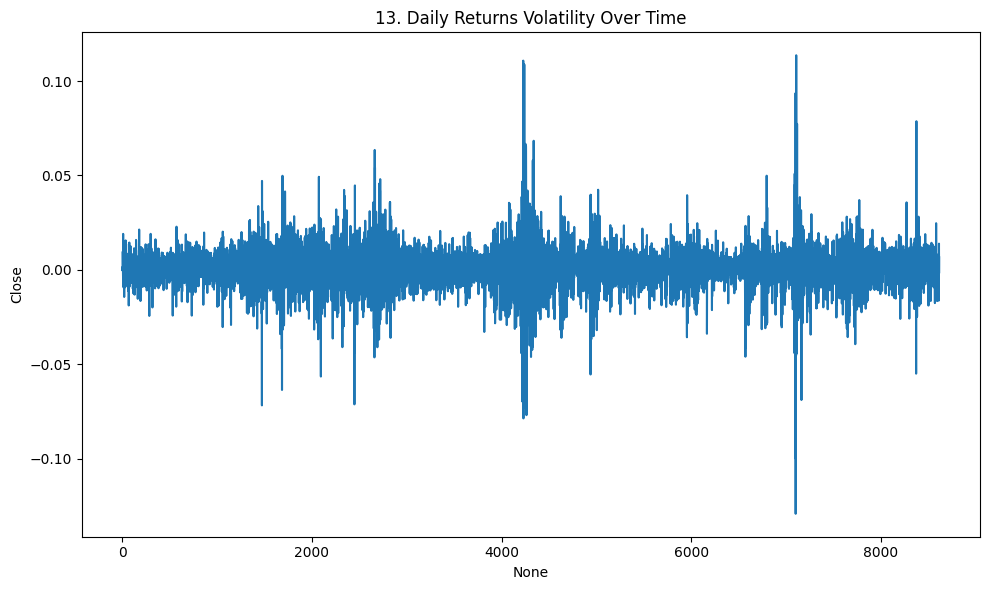

In [25]:
fig = plt.figure(figsize=(10,6))
sns.lineplot(x=df.index, y=returns)
plt.title(f'{plot_no}. Daily Returns Volatility Over Time')
show_fig()
plot_no += 1

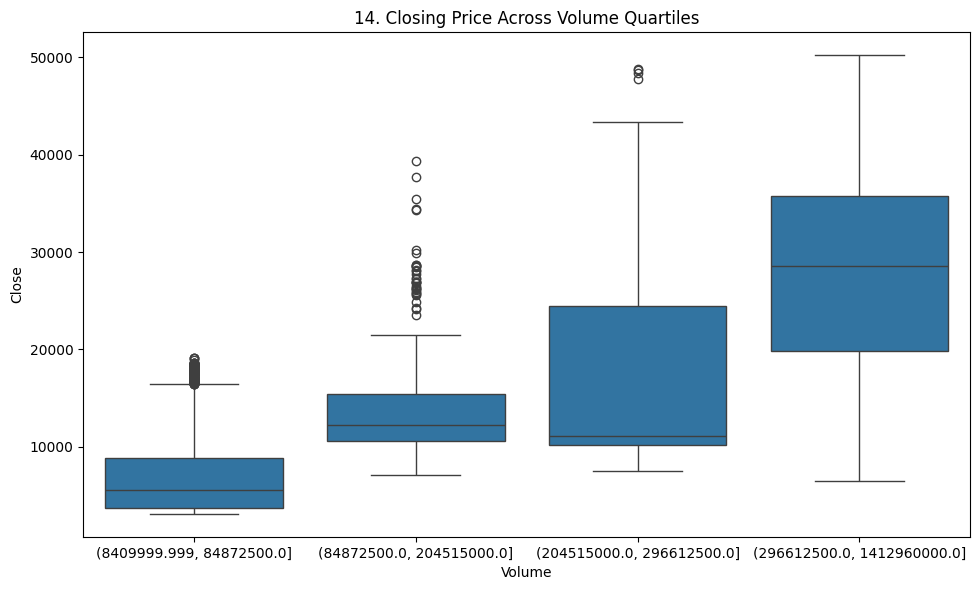

In [26]:
fig = plt.figure(figsize=(10,6))
sns.boxplot(x=pd.qcut(df['Volume'], 4), y=df['Close'])
plt.title(f'{plot_no}. Closing Price Across Volume Quartiles')
show_fig()
plot_no += 1

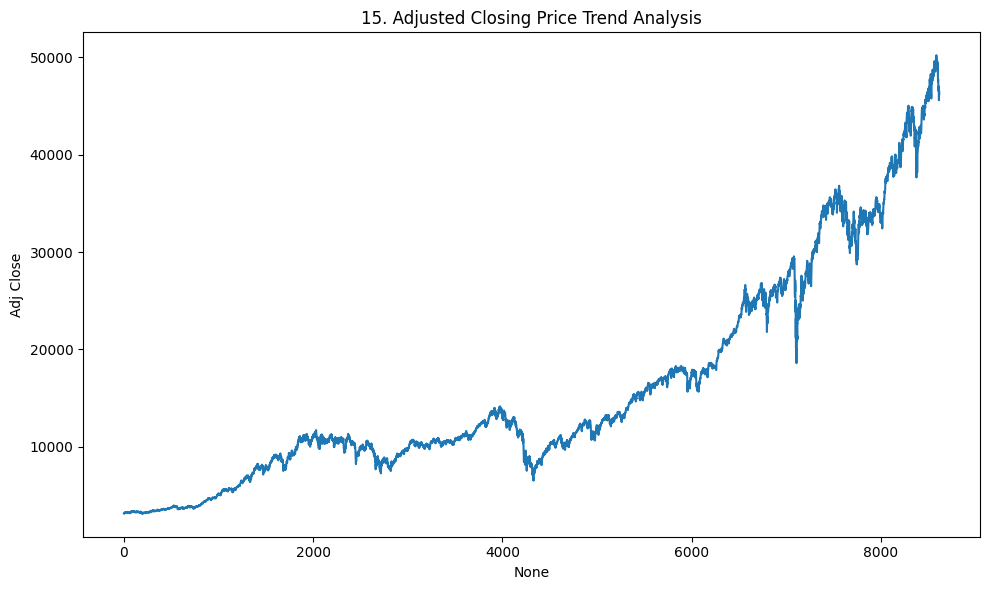

In [27]:
fig = plt.figure(figsize=(10,6))
sns.lineplot(x=df.index, y=df['Adj Close'])
plt.title(f'{plot_no}. Adjusted Closing Price Trend Analysis')
show_fig()
plot_no += 1

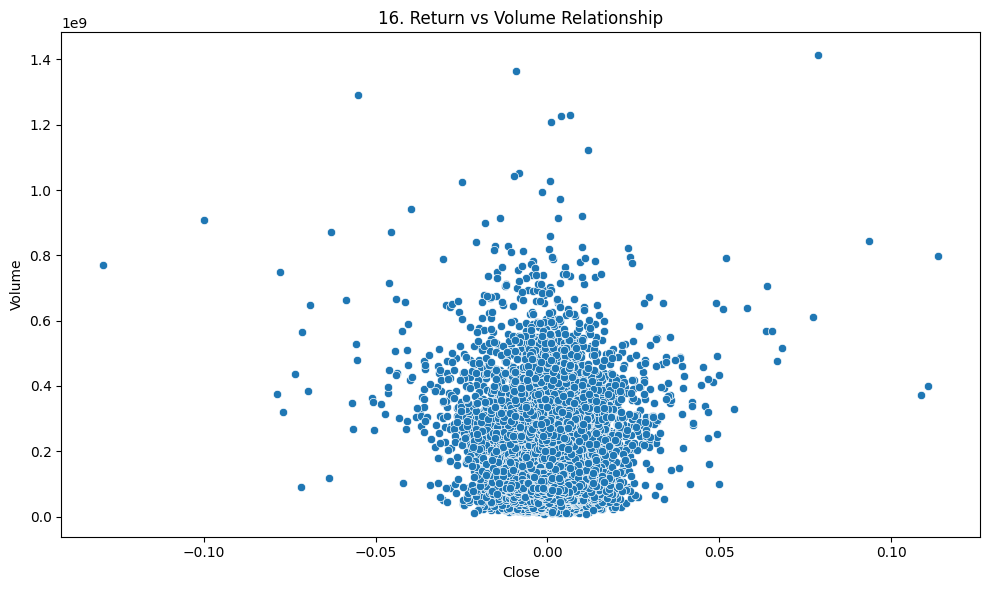

In [28]:
fig = plt.figure(figsize=(10,6))
sns.scatterplot(x=returns, y=df['Volume'])
plt.title(f'{plot_no}. Return vs Volume Relationship')
show_fig()
plot_no += 1

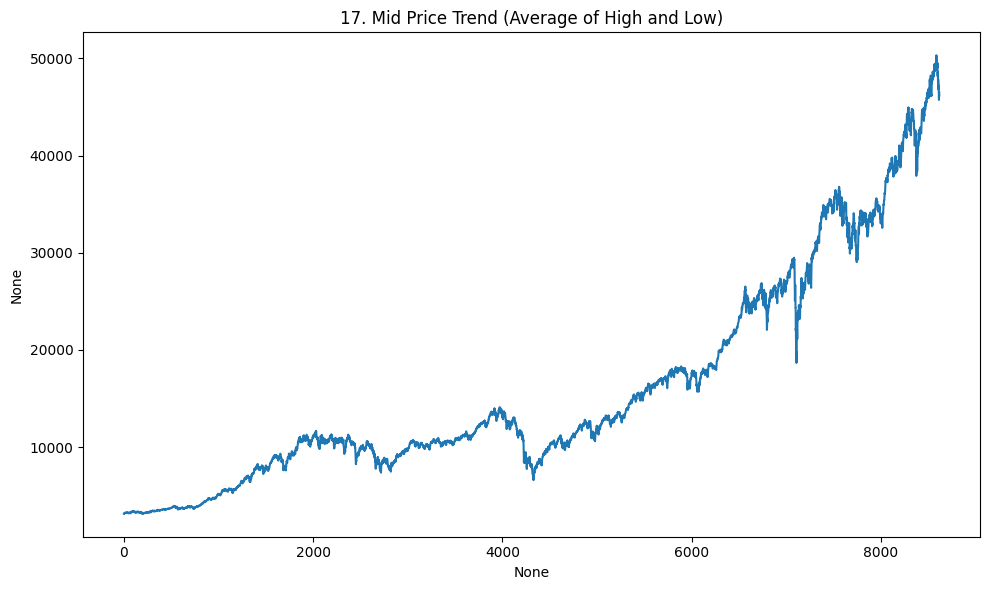

In [29]:
fig = plt.figure(figsize=(10,6))
sns.lineplot(x=df.index, y=(df['High']+df['Low'])/2)
plt.title(f'{plot_no}. Mid Price Trend (Average of High and Low)')
show_fig()
plot_no += 1

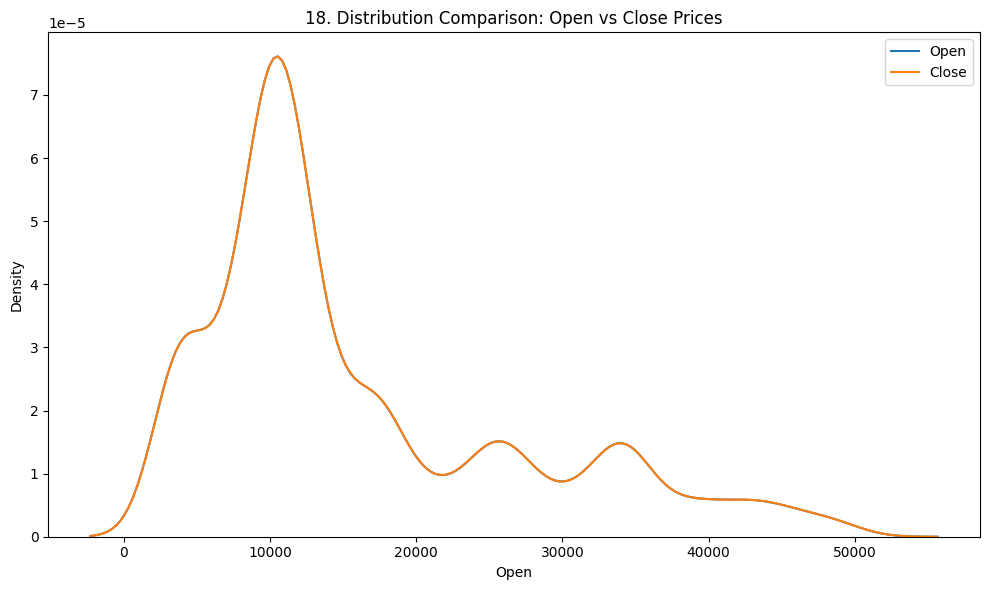

In [30]:
fig = plt.figure(figsize=(10,6))
sns.kdeplot(df['Open'], label='Open')
sns.kdeplot(df['Close'], label='Close')
plt.legend()
plt.title(f'{plot_no}. Distribution Comparison: Open vs Close Prices')
show_fig()
plot_no += 1

# Model Training

## create useful features

In [31]:
df['Return'] = df['Close'].pct_change()
df['Volatility'] = df['High'] - df['Low']
df['MA50'] = df['Close'].rolling(50).mean()
df['MA200'] = df['Close'].rolling(200).mean()
df = df.dropna()

## define features and target

In [32]:
X = df[['Open','High','Low','Volume','Volatility','MA50','MA200']]
y = df['Close']

## split the data

In [33]:
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, shuffle=False)

## scale the features

In [34]:
scaler = StandardScaler()
X_train = scaler.fit_transform(X_train)
X_test = scaler.transform(X_test)

## train regression model

In [35]:
model = Ridge()
model.fit(X_train, y_train)

Ridge()

## predictions

In [36]:
y_pred = model.predict(X_test)

## print model accuracy

In [37]:
print("R2 Score:", r2_score(y_test, y_pred))

R2 Score: 0.9993700937140766


## plot actual vs predicted

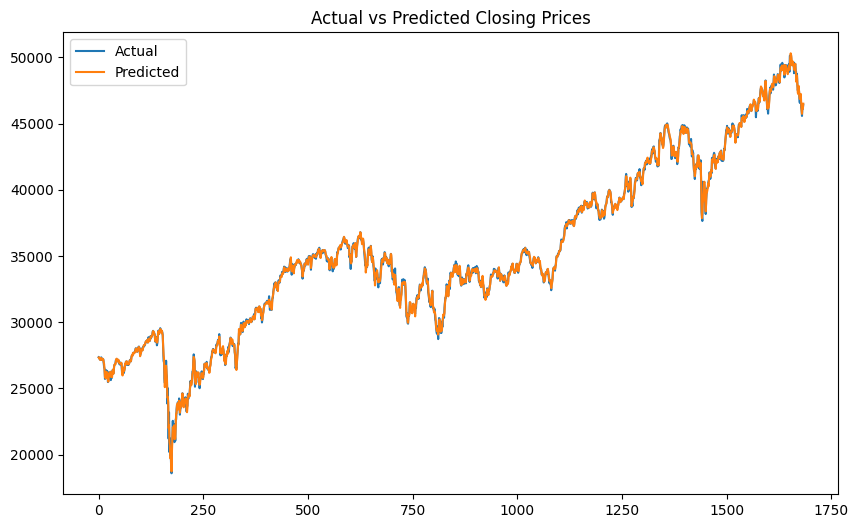

In [38]:
plt.figure(figsize=(10,6))
plt.plot(y_test.values, label='Actual')
plt.plot(y_pred, label='Predicted')
plt.legend()
plt.title('Actual vs Predicted Closing Prices')
plt.show()